In [ ]:
!pip install ucimlrepo

## Importing libraries

In [ ]:
import pandas as pd
from ucimlrepo import fetch_ucirepo
import seaborn as sbn
import matplotlib.pyplot as plt
import numpy as np

## Getting data

In [ ]:
musk_data = fetch_ucirepo(id=74)

In [ ]:
musk_data.data.musk_target

In [ ]:
musk_features = pd.DataFrame(musk_data.data.features)
musk_df = pd.DataFrame(musk_data.data.original)
musk_target = pd.DataFrame(musk_data.data.original).iloc[:,-1]

musk_df

,molecule_name,conformation_name,f1,f2,f3,f4,f5,f6,f7,f8,...,f158,f159,f160,f161,f162,f163,f164,f165,f166,class
0,MUSK-188,188_1+1,42,-198,-109,-75,-117,11,23,-88,...,-74,-129,-120,-38,30,48,-37,6,30,1.0
1,MUSK-188,188_1+2,42,-191,-142,-65,-117,55,49,-170,...,-302,60,-120,-39,31,48,-37,5,30,1.0
2,MUSK-188,188_1+3,42,-191,-142,-75,-117,11,49,-161,...,-73,-127,-120,-38,30,48,-37,5,31,1.0
3,MUSK-188,188_1+4,42,-198,-110,-65,-117,55,23,-95,...,-302,60,-120,-39,30,48,-37,6,30,1.0
4,MUSK-190,190_1+1,42,-198,-102,-75,-117,10,24,-87,...,-73,-127,51,128,144,43,-30,14,26,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
471,NON-MUSK-jp13,jp13_1+4,49,-199,-161,29,-95,-86,-48,2,...,-246,-209,33,152,134,47,-43,-15,-10,0.0
472,NON-MUSK-jp13,jp13_2+1,38,-123,-139,30,-117,-88,214,-13,...,-226,-210,20,55,119,79,-28,4,74,0.0
473,NON-MUSK-jp13,jp13_2+2,43,-102,-20,-101,-116,200,-166,66,...,32,136,-15,143,121,55,-37,-19,-36,0.0
474,NON-MUSK-jp13,jp13_2+3,39,-58,27,31,-117,-92,85,21,...,-232,-206,13,45,116,79,-28,3,74,0.0


## Getting missing values

In [ ]:
if (musk_df.isna().sum().sum() == 0):
  print("No null values")
else :
  for col in musk_df.columns:
    null_count = musk_df[col].isna().sum()
    if (null_count > 0):
      print(f"{col} has {null_count} null values")

No null values


## Removing nominal non-contributing features from data

In [ ]:
musk_features = musk_features.drop(columns=["molecule_name","conformation_name"])
musk_df = musk_df.drop(columns=["molecule_name","conformation_name"])
musk_df

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,...,f158,f159,f160,f161,f162,f163,f164,f165,f166,class
0,42,-198,-109,-75,-117,11,23,-88,-28,-27,...,-74,-129,-120,-38,30,48,-37,6,30,1.0
1,42,-191,-142,-65,-117,55,49,-170,-45,5,...,-302,60,-120,-39,31,48,-37,5,30,1.0
2,42,-191,-142,-75,-117,11,49,-161,-45,-28,...,-73,-127,-120,-38,30,48,-37,5,31,1.0
3,42,-198,-110,-65,-117,55,23,-95,-28,5,...,-302,60,-120,-39,30,48,-37,6,30,1.0
4,42,-198,-102,-75,-117,10,24,-87,-28,-28,...,-73,-127,51,128,144,43,-30,14,26,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
471,49,-199,-161,29,-95,-86,-48,2,112,-79,...,-246,-209,33,152,134,47,-43,-15,-10,0.0
472,38,-123,-139,30,-117,-88,214,-13,-74,-129,...,-226,-210,20,55,119,79,-28,4,74,0.0
473,43,-102,-20,-101,-116,200,-166,66,-222,-49,...,32,136,-15,143,121,55,-37,-19,-36,0.0
474,39,-58,27,31,-117,-92,85,21,-73,-68,...,-232,-206,13,45,116,79,-28,3,74,0.0


In [ ]:
musk_features.describe()

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,...,f157,f158,f159,f160,f161,f162,f163,f164,f165,f166
count,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000,...,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000
mean,38.731092,-120.142857,-79.243697,15.903361,-112.298319,-9.760504,-16.628151,7.762605,-91.048319,-76.077731,...,-221.728992,-204.405462,-108.262605,-25.231092,37.428571,79.752101,85.363445,-34.128151,-26.241597,33.714286
std,18.087948,88.313464,69.172519,75.515959,28.704947,92.025496,106.560891,75.786461,96.321303,72.467693,...,63.021801,89.566426,121.794583,65.588295,87.315888,49.269244,47.487575,16.019277,58.009205,54.189087
min,-9.000000,-199.000000,-166.000000,-115.000000,-117.000000,-184.000000,-170.000000,-231.000000,-242.000000,-284.000000,...,-252.000000,-324.000000,-217.000000,-135.000000,-126.000000,-78.000000,35.000000,-132.000000,-258.000000,-72.000000
25%,31.000000,-193.000000,-144.000000,-53.000000,-117.000000,-89.000000,-159.000000,-9.250000,-215.000000,-118.250000,...,-240.000000,-264.000000,-208.000000,-91.000000,-39.250000,33.000000,54.000000,-42.250000,-28.000000,-12.000000
50%,42.000000,-144.500000,-108.000000,28.000000,-117.000000,11.000000,41.000000,18.000000,-41.000000,-73.500000,...,-236.000000,-236.000000,-189.500000,-15.000000,31.500000,84.000000,69.000000,-36.000000,-11.000000,35.000000
75%,50.000000,-101.000000,-21.000000,38.000000,-117.000000,70.250000,51.000000,57.000000,-30.000000,-28.000000,...,-232.000000,-154.750000,30.000000,22.000000,128.000000,119.000000,99.000000,-28.000000,7.000000,74.000000
max,130.000000,98.000000,83.000000,157.000000,238.000000,200.000000,214.000000,188.000000,135.000000,218.000000,...,141.000000,72.000000,173.000000,185.000000,253.000000,291.000000,302.000000,24.000000,82.000000,235.000000


In [ ]:
musk_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 476 entries, 0 to 475
Columns: 166 entries, f1 to f166
dtypes: int64(166)
memory usage: 617.4 KB


## Getting outliers

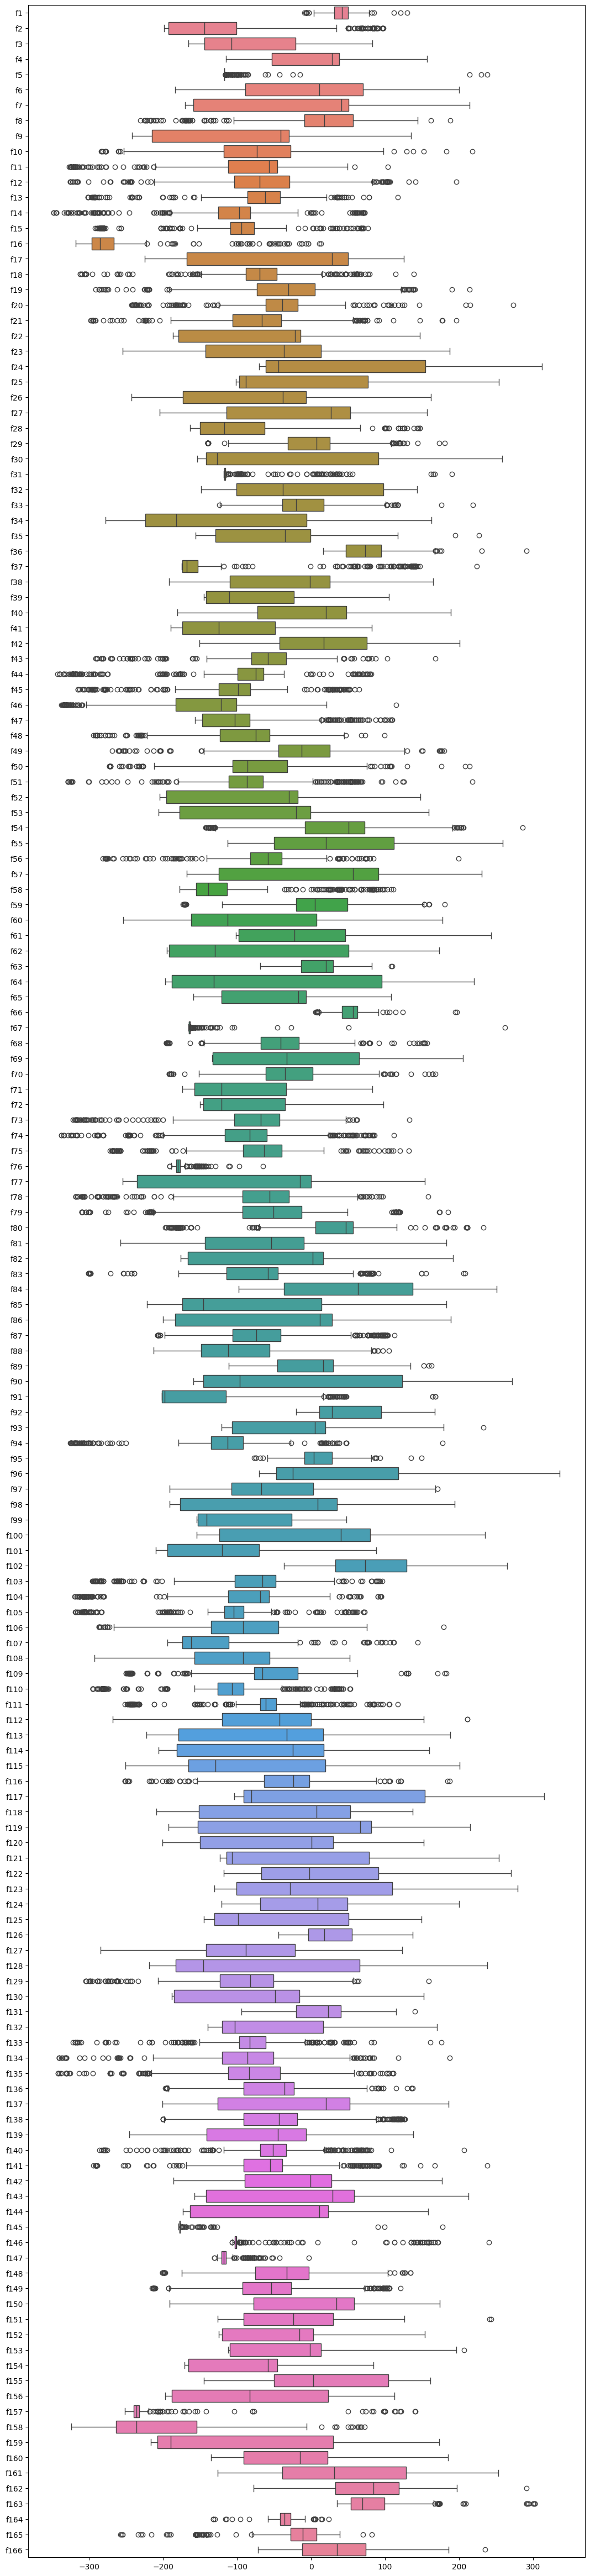

In [ ]:
plt.figure(figsize=(13,60))
sbn.boxplot(musk_features,orient="h")
plt.show()

### Outliers percentage

In [ ]:
def outlier_percentage_df(df):
    results = {}
    for col in df.select_dtypes(include=[np.number]).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        mask = (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)
        results[col] = round((mask.sum() / len(df)) * 100, 2)
    return pd.DataFrame.from_dict(results, orient='index', columns=['Outlier %']).sort_values(by="Outlier %",ascending=False)

outlier_percentage_df(musk_features)

,Outlier %
f111,28.99
f110,26.68
f105,26.05
f45,25.21
f44,23.95
...,...
f154,0.00
f155,0.00
f161,0.00
f159,0.00


### Imputing outliers

In [ ]:
def impute_outliers_df(df, lower_pct=0.05, upper_pct=0.95):
    df_imputed = df.copy()
    for col in df.select_dtypes(include=[np.number]).columns:
        lower = df[col].quantile(lower_pct)
        upper = df[col].quantile(upper_pct)
        median = df[col].median()

        mask = (df[col] < lower) | (df[col] > upper)
        df_imputed.loc[mask, col] = median
    return df_imputed

musk_features = impute_outliers_df(musk_features)

/tmp/ipykernel_483/4139854905.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-144.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_imputed.loc[mask, col] = median
/tmp/ipykernel_483/4139854905.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-73.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_imputed.loc[mask, col] = median
/tmp/ipykernel_483/4139854905.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-69.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_imputed.loc[mask, col] = median
/tmp/ipykernel_483/4139854905.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will

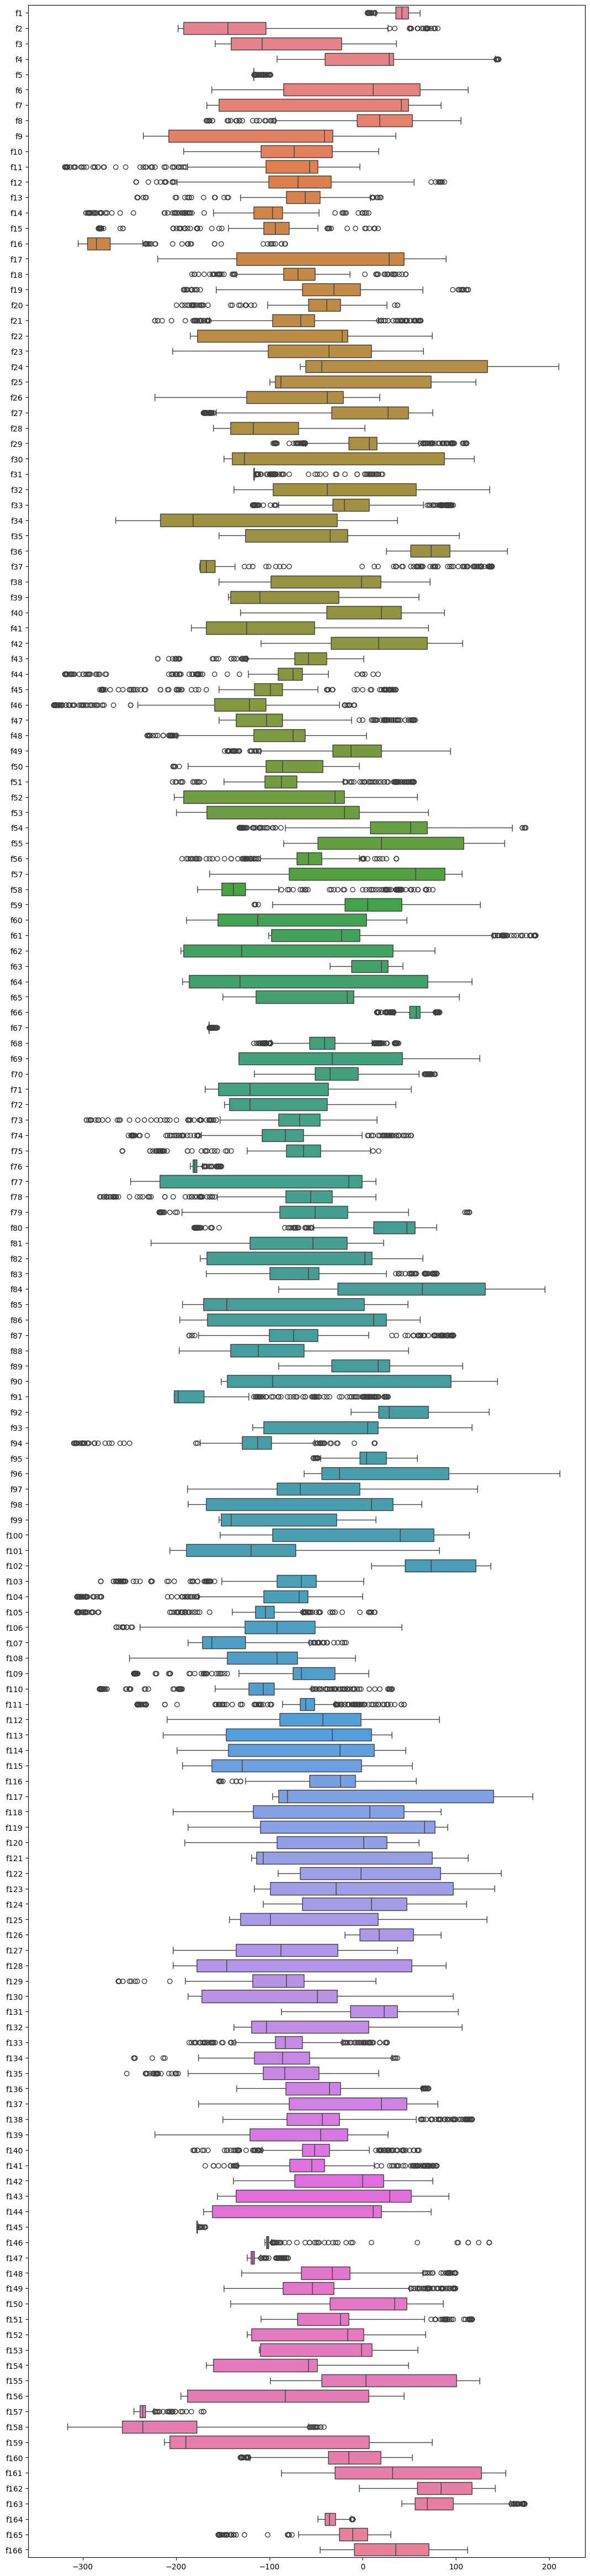

In [ ]:
plt.figure(figsize=(13,60))
sbn.boxplot(musk_features,orient="h")
plt.show()

### Outliers percentage

In [ ]:
outlier_percentage_df(musk_features)

,Outlier %
f111,24.16
f68,23.74
f67,23.32
f110,21.01
f29,20.80
...,...
f154,0.00
f162,0.00
f161,0.00
f159,0.00


## Normalizing and encoding data

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [ ]:
sc = StandardScaler()
musk_features_std = pd.DataFrame(sc.fit_transform(musk_features),columns=musk_features.columns)
musk_features_std

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,...,f157,f158,f159,f160,f161,f162,f163,f164,f165,f166
0,0.189617,-0.923105,-0.414204,-1.442709,-0.288819,0.221582,0.423349,-1.928471,0.741475,0.957358,...,-0.381307,1.970701,-0.060806,-1.697890,-1.017414,-1.318477,-0.932256,-0.312728,0.604170,-0.075979
1,0.189617,-0.827537,-0.946855,-1.286449,-0.288819,0.791215,0.699411,0.091352,0.541455,1.597109,...,-0.381307,-1.261034,1.671696,-1.697890,-1.030315,-1.292640,-0.932256,-0.312728,0.580983,-0.075979
2,0.189617,-0.827537,-0.946855,-1.442709,-0.288819,0.221582,0.699411,-3.319482,0.541455,0.937366,...,-0.381307,1.984876,-0.042473,-1.697890,-1.017414,-1.318477,-0.932256,-0.312728,0.580983,-0.053805
3,0.189617,-0.923105,-0.430345,-1.286449,-0.288819,0.791215,0.423349,-2.061856,0.741475,1.597109,...,-0.381307,-1.261034,1.671696,-1.697890,-1.030315,-1.318477,-0.932256,-0.312728,0.604170,-0.075979
4,0.189617,-0.923105,-0.301218,-1.442709,-0.288819,0.208635,0.433967,-1.909417,0.741475,0.937366,...,-0.381307,1.984876,-0.042473,1.386138,1.124230,0.076753,-1.073121,0.464891,0.789664,-0.164675
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
471,0.711768,-0.192698,-0.398063,0.182390,-0.288819,-1.034201,-0.330511,-0.213527,0.588518,-0.082237,...,1.543876,-0.467275,-0.794140,1.061503,1.433865,1.368633,-0.960429,-0.979259,0.117249,-0.962943
472,-0.108755,0.100830,-0.898432,0.198016,-0.288819,-1.060094,0.614469,-0.499351,0.200243,-1.081847,...,-0.167397,-0.183789,-0.803307,0.827045,0.182423,0.981069,-0.058891,0.687068,0.557796,0.899681
473,0.264210,0.387532,1.022337,0.166764,0.033143,0.221582,-1.583406,1.005988,-1.541112,0.517529,...,-0.167397,-0.325532,-0.615390,0.195811,1.317752,1.032744,-0.735044,-0.312728,0.024502,-1.539469
474,-0.034162,0.988241,1.780960,0.213642,-0.288819,-1.111879,0.614469,0.148516,0.212009,0.137677,...,0.688239,-0.268835,-0.766640,0.700798,0.053408,0.903556,-0.058891,0.687068,0.534610,0.899681


In [ ]:
musk_df = pd.concat([musk_features_std, musk_df['class']], axis=1)

In [ ]:
musk_df

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,...,f158,f159,f160,f161,f162,f163,f164,f165,f166,class
0,0.189617,-0.923105,-0.414204,-1.442709,-0.288819,0.221582,0.423349,-1.928471,0.741475,0.957358,...,1.970701,-0.060806,-1.697890,-1.017414,-1.318477,-0.932256,-0.312728,0.604170,-0.075979,1.0
1,0.189617,-0.827537,-0.946855,-1.286449,-0.288819,0.791215,0.699411,0.091352,0.541455,1.597109,...,-1.261034,1.671696,-1.697890,-1.030315,-1.292640,-0.932256,-0.312728,0.580983,-0.075979,1.0
2,0.189617,-0.827537,-0.946855,-1.442709,-0.288819,0.221582,0.699411,-3.319482,0.541455,0.937366,...,1.984876,-0.042473,-1.697890,-1.017414,-1.318477,-0.932256,-0.312728,0.580983,-0.053805,1.0
3,0.189617,-0.923105,-0.430345,-1.286449,-0.288819,0.791215,0.423349,-2.061856,0.741475,1.597109,...,-1.261034,1.671696,-1.697890,-1.030315,-1.318477,-0.932256,-0.312728,0.604170,-0.075979,1.0
4,0.189617,-0.923105,-0.301218,-1.442709,-0.288819,0.208635,0.433967,-1.909417,0.741475,0.937366,...,1.984876,-0.042473,1.386138,1.124230,0.076753,-1.073121,0.464891,0.789664,-0.164675,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
471,0.711768,-0.192698,-0.398063,0.182390,-0.288819,-1.034201,-0.330511,-0.213527,0.588518,-0.082237,...,-0.467275,-0.794140,1.061503,1.433865,1.368633,-0.960429,-0.979259,0.117249,-0.962943,0.0
472,-0.108755,0.100830,-0.898432,0.198016,-0.288819,-1.060094,0.614469,-0.499351,0.200243,-1.081847,...,-0.183789,-0.803307,0.827045,0.182423,0.981069,-0.058891,0.687068,0.557796,0.899681,0.0
473,0.264210,0.387532,1.022337,0.166764,0.033143,0.221582,-1.583406,1.005988,-1.541112,0.517529,...,-0.325532,-0.615390,0.195811,1.317752,1.032744,-0.735044,-0.312728,0.024502,-1.539469,0.0
474,-0.034162,0.988241,1.780960,0.213642,-0.288819,-1.111879,0.614469,0.148516,0.212009,0.137677,...,-0.268835,-0.766640,0.700798,0.053408,0.903556,-0.058891,0.687068,0.534610,0.899681,0.0


<Axes: >

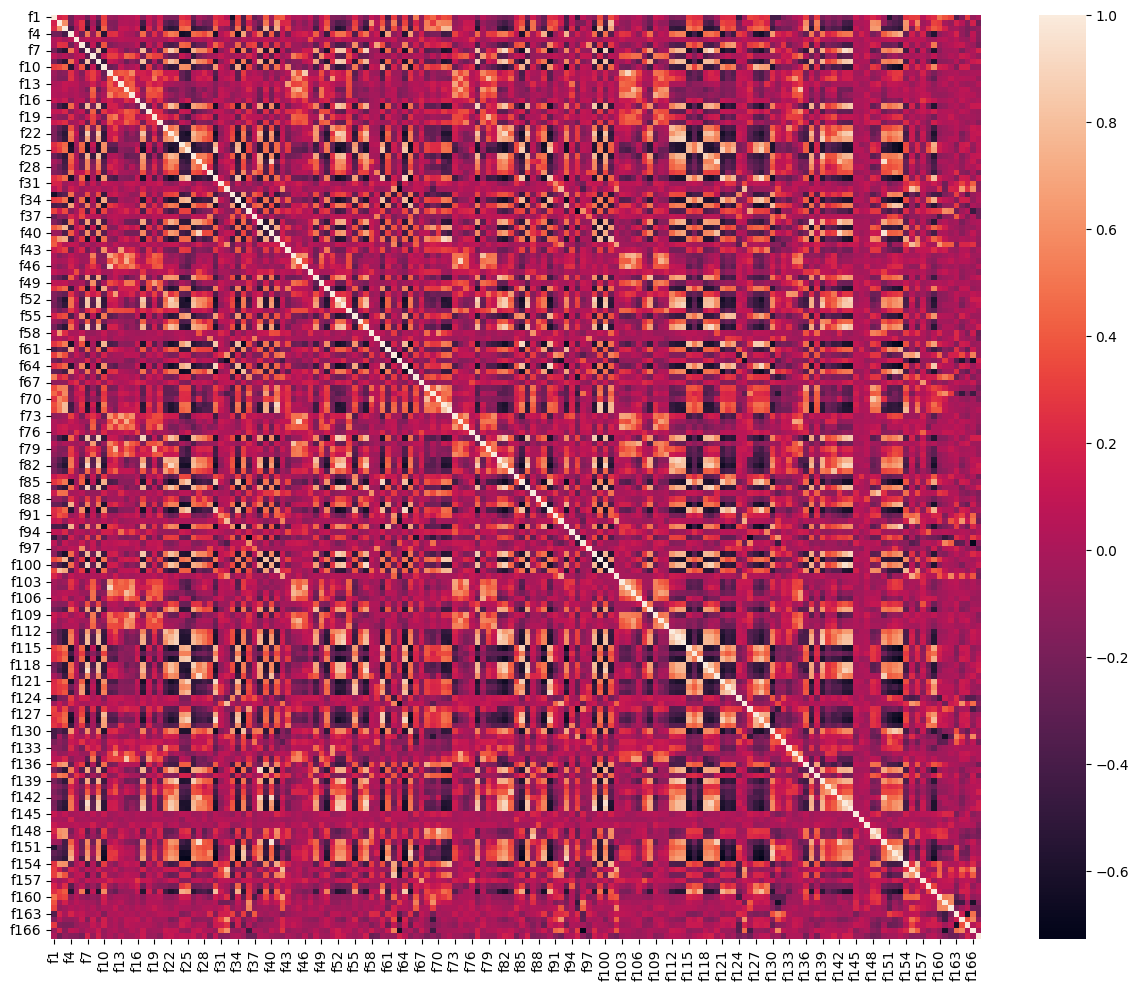

In [ ]:
plt.figure(figsize=(15,12))
sbn.heatmap(musk_df.corr())

## Reducing features using PCA (High no. of dimensions)

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(70)
musk_pca = pd.DataFrame(pca.fit_transform(musk_features_std))
musk_pca

,0,1,2,3,4,5,6,7,8,9,...,60,61,62,63,64,65,66,67,68,69
0,-0.909213,-13.473418,-3.369254,-0.674984,-1.863345,-1.697209,4.129386,-2.149969,0.413202,1.539589,...,0.412614,0.429701,-0.636492,-0.386552,-0.632125,0.200357,-0.006449,-0.472595,0.240779,0.134532
1,-0.276744,-9.464372,-3.833614,0.530776,-2.643030,-1.378857,4.299553,1.594529,-0.626325,-3.778372,...,-0.193614,0.159149,0.397397,-0.113526,0.241081,0.703559,-0.127371,-1.137591,0.740906,-0.131817
2,-0.101764,-13.616724,-3.330869,-0.013723,-2.837631,-1.002460,4.565229,1.061213,1.342052,0.348277,...,-0.407299,-0.117501,0.507426,-0.237225,0.167948,0.882806,0.404179,0.019734,0.569749,-0.032809
3,-1.633184,-13.649835,-3.737342,0.144703,-1.059147,-1.458854,2.652729,-0.114095,-0.991629,-0.571864,...,0.760432,0.300919,-0.110338,0.092237,-0.200062,0.163673,-0.260774,0.547313,0.551193,-0.013933
4,-1.652537,-14.027740,0.137814,0.626790,-3.667727,0.677377,1.872274,-2.792973,0.857924,1.497146,...,-0.496195,0.481641,-0.221689,-0.023737,-0.087806,-0.002617,0.758356,-0.530657,-0.093567,0.569057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
471,3.985959,2.004738,-1.279534,-2.257097,-3.459491,0.783608,-2.619620,-1.810113,1.151560,0.548057,...,-0.338625,-1.200445,-1.308024,1.094003,0.618864,-0.751784,0.257636,-0.780773,-0.059987,-0.296274
472,4.831281,1.204144,3.500677,3.002622,-1.627997,-0.699723,-1.765021,-0.225076,-0.590973,-0.418223,...,-0.113263,-0.067613,-0.463963,0.280115,0.162332,-0.872620,-0.058043,0.375923,-0.294777,-0.425710
473,-10.484142,3.406493,-3.522235,-2.544705,-0.625278,1.264841,-3.007545,-1.203560,0.833563,2.354681,...,-0.028248,-0.592584,-0.118346,-0.126884,1.007157,0.082022,-0.302702,-0.468517,0.372599,-0.533392
474,2.940922,1.506940,6.568657,1.268473,0.210847,-1.344612,-0.728755,-1.045793,1.665345,-0.559020,...,-1.170020,0.556593,-0.787077,0.381828,0.211709,-0.756500,-0.085654,-0.111918,0.083241,-0.618808


In [ ]:
musk_df = pd.concat([musk_pca, musk_df['class']], axis=1)


## Visualizing variance over no. of components

PCA Shape     : (476, 166) → (476, 70)
Variance Retained: 95.05%


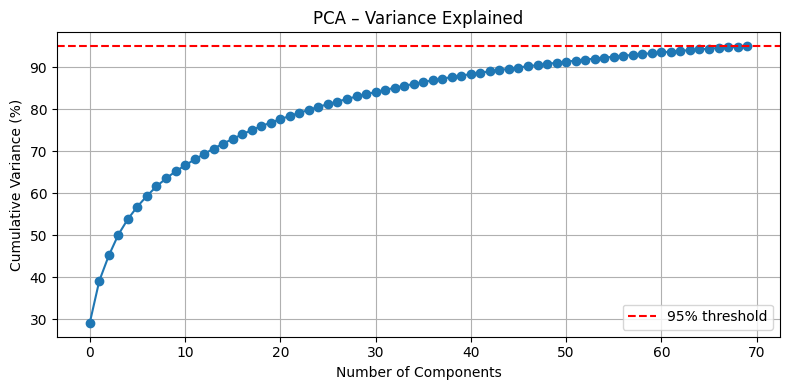

In [ ]:
variance_retained = sum(pca.explained_variance_ratio_) * 100
print(f"PCA Shape     : {musk_features_std.shape} → {musk_pca.shape}")
print(f"Variance Retained: {variance_retained:.2f}%")

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_ * 100), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance (%)')
plt.title('PCA – Variance Explained')
plt.axhline(y=95, color='r', linestyle='--', label='95% threshold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## t-SNE visualizing dataset

In [ ]:
from sklearn.manifold import TSNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    n_iter=1000,
    random_state=42
)
musk_tsne = tsne.fit_transform(musk_pca)

print(f"t-SNE Shape: {musk_pca.shape} → {musk_tsne.shape}")

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE Shape: (476, 70) → (476, 2)


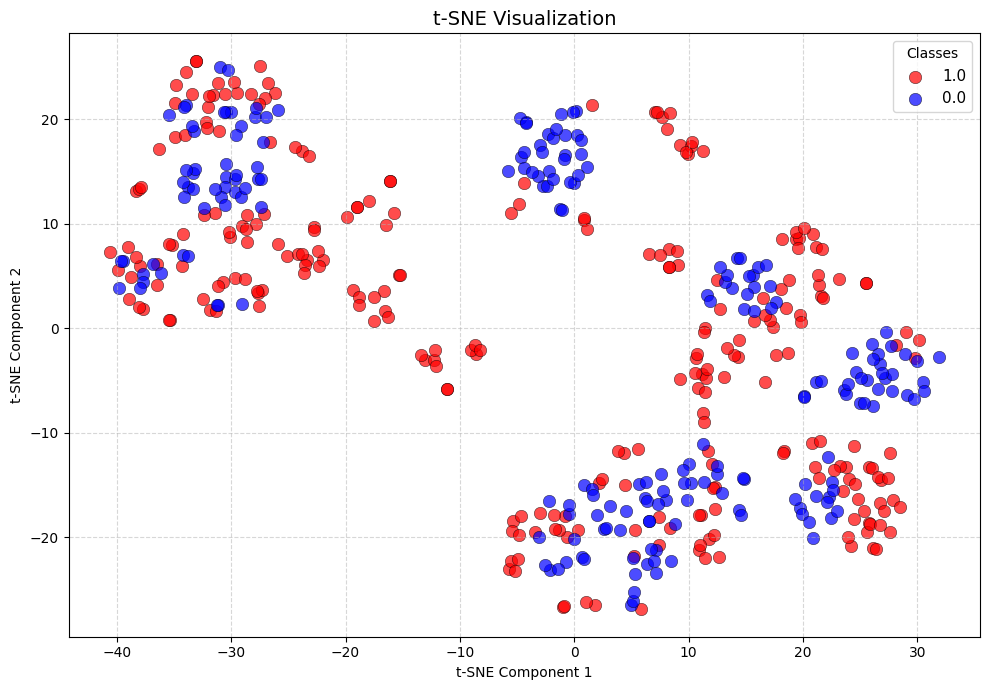

In [ ]:
plt.figure(figsize=(10, 7))

colors = ['red', 'blue', 'green']

for i, label in enumerate(musk_target.unique()):
    mask = musk_target == i
    plt.scatter(
        musk_tsne[mask, 0],
        musk_tsne[mask, 1],
        c=colors[i],
        label=label,
        alpha=0.7,
        edgecolors='k',
        linewidths=0.4,
        s=80
    )

plt.title('t-SNE Visualization', fontsize=14)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(title='Classes', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Discretization (K-Means binning due to natual clusters in data)

In [ ]:
def bin_all_numeric(df, n_bins=4, strategy='quantile'):
    df_binned = pd.DataFrame(index=df.index)
    from sklearn.preprocessing import KBinsDiscretizer

    for col in df.select_dtypes(include=[np.number]).columns:
        kbd = KBinsDiscretizer(n_bins=n_bins,
                               encode='ordinal',
                               strategy=strategy)
        df_binned[f'{col}'] = kbd.fit_transform(df[[col]])
    return df_binned

musk_binned_pca = bin_all_numeric(musk_pca, n_bins=4)

In [ ]:
musk_binned_pca

,0,1,2,3,4,5,6,7,8,9,...,60,61,62,63,64,65,66,67,68,69
0,1.0,0.0,0.0,1.0,0.0,1.0,3.0,0.0,2.0,3.0,...,3.0,3.0,0.0,0.0,0.0,2.0,2.0,0.0,2.0,2.0
1,1.0,0.0,0.0,2.0,0.0,1.0,3.0,3.0,1.0,0.0,...,1.0,2.0,3.0,1.0,2.0,3.0,1.0,0.0,3.0,1.0
2,1.0,0.0,0.0,1.0,0.0,1.0,3.0,3.0,3.0,2.0,...,0.0,1.0,3.0,1.0,2.0,3.0,3.0,2.0,3.0,1.0
3,1.0,0.0,0.0,2.0,1.0,1.0,3.0,2.0,1.0,1.0,...,3.0,2.0,1.0,2.0,1.0,2.0,1.0,3.0,3.0,2.0
4,1.0,0.0,2.0,2.0,0.0,2.0,3.0,0.0,2.0,3.0,...,0.0,3.0,1.0,1.0,1.0,1.0,3.0,0.0,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
471,2.0,2.0,1.0,1.0,0.0,2.0,0.0,0.0,3.0,2.0,...,1.0,0.0,0.0,3.0,3.0,0.0,2.0,0.0,1.0,1.0
472,2.0,2.0,3.0,3.0,1.0,1.0,0.0,1.0,1.0,1.0,...,1.0,1.0,0.0,2.0,2.0,0.0,1.0,3.0,0.0,0.0
473,0.0,3.0,0.0,0.0,1.0,2.0,0.0,0.0,2.0,3.0,...,1.0,0.0,1.0,1.0,3.0,2.0,0.0,0.0,3.0,0.0
474,1.0,2.0,3.0,2.0,2.0,1.0,1.0,1.0,3.0,1.0,...,0.0,3.0,0.0,3.0,2.0,0.0,1.0,1.0,2.0,0.0


In [ ]:
musk_df = pd.concat([musk_binned_pca, musk_df['class']], axis=1)

In [ ]:
musk_df

,0,1,2,3,4,5,6,7,8,9,...,61,62,63,64,65,66,67,68,69,class
0,1.0,0.0,0.0,1.0,0.0,1.0,3.0,0.0,2.0,3.0,...,3.0,0.0,0.0,0.0,2.0,2.0,0.0,2.0,2.0,1.0
1,1.0,0.0,0.0,2.0,0.0,1.0,3.0,3.0,1.0,0.0,...,2.0,3.0,1.0,2.0,3.0,1.0,0.0,3.0,1.0,1.0
2,1.0,0.0,0.0,1.0,0.0,1.0,3.0,3.0,3.0,2.0,...,1.0,3.0,1.0,2.0,3.0,3.0,2.0,3.0,1.0,1.0
3,1.0,0.0,0.0,2.0,1.0,1.0,3.0,2.0,1.0,1.0,...,2.0,1.0,2.0,1.0,2.0,1.0,3.0,3.0,2.0,1.0
4,1.0,0.0,2.0,2.0,0.0,2.0,3.0,0.0,2.0,3.0,...,3.0,1.0,1.0,1.0,1.0,3.0,0.0,1.0,3.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
471,2.0,2.0,1.0,1.0,0.0,2.0,0.0,0.0,3.0,2.0,...,0.0,0.0,3.0,3.0,0.0,2.0,0.0,1.0,1.0,0.0
472,2.0,2.0,3.0,3.0,1.0,1.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,2.0,0.0,1.0,3.0,0.0,0.0,0.0
473,0.0,3.0,0.0,0.0,1.0,2.0,0.0,0.0,2.0,3.0,...,0.0,1.0,1.0,3.0,2.0,0.0,0.0,3.0,0.0,0.0
474,1.0,2.0,3.0,2.0,2.0,1.0,1.0,1.0,3.0,1.0,...,3.0,0.0,3.0,2.0,0.0,1.0,1.0,2.0,0.0,0.0


<Axes: >

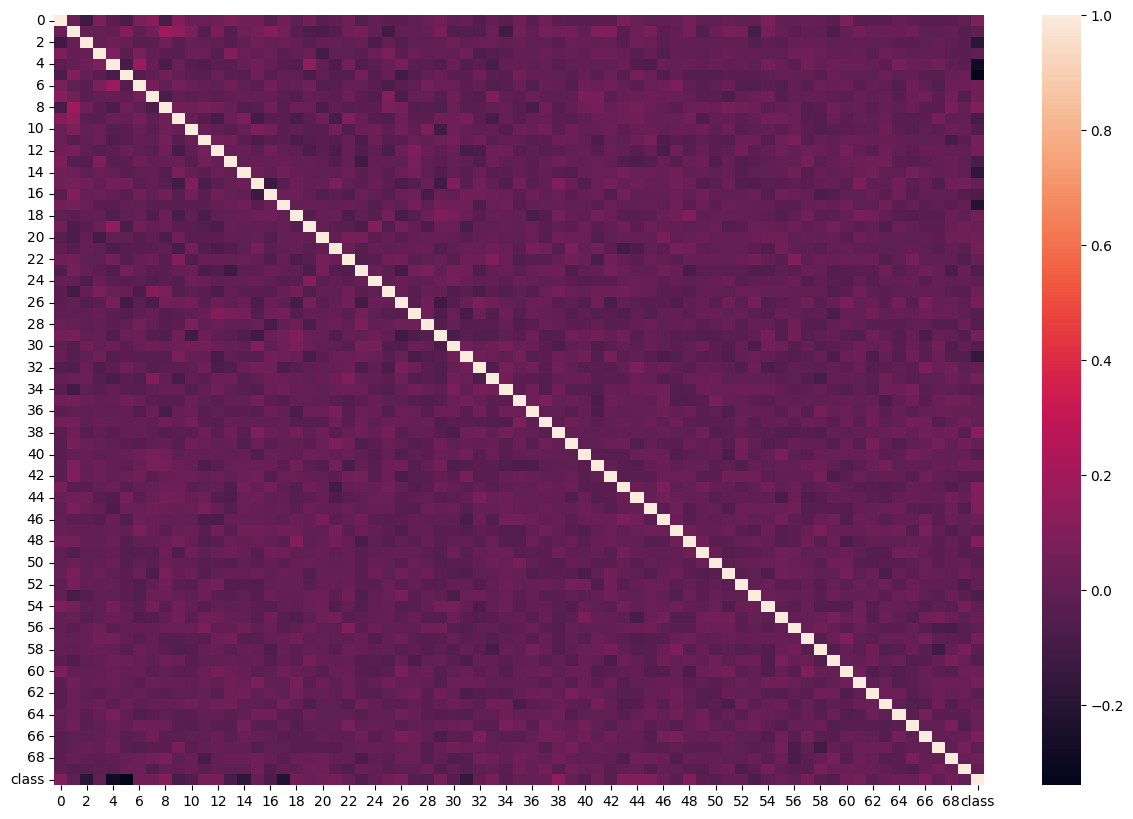

In [ ]:
plt.figure(figsize=(15,10))
sbn.heatmap(musk_df.corr())